<a href="https://colab.research.google.com/github/hafizzx/python-projects/blob/main/ML%20Linear%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error,r2_score

In [ ]:
df = pd.read_csv("/content/students_cgpa_salary.csv")

In [ ]:
df.head(5)

,cgpa,salary
0,1.00,50000
1,4.00,428000
2,3.35,264000
3,3.46,340000
4,1.73,67000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cgpa    100 non-null    float64
 1   salary  100 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [ ]:
df.describe()

,cgpa,salary
count,100.000000,100.000000
mean,2.864700,236070.000000
std,0.506893,82585.157152
min,1.000000,50000.000000
25%,2.572500,191000.000000
50%,2.900000,227500.000000
75%,3.235000,284500.000000
max,4.000000,454000.000000


In [ ]:
df.shape

(100, 2)

In [ ]:
import plotly.express as px

fig = px.line(
    df,
    y=["cgpa", "salary"],
    title="CGPA and Salary"
)

fig.show()

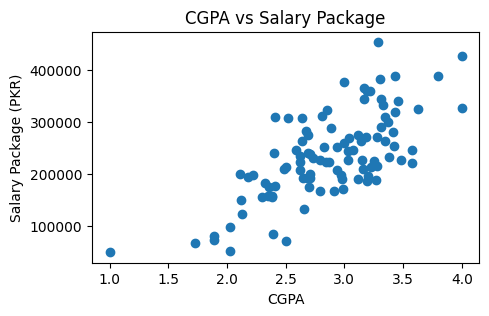

In [ ]:
plt.figure(figsize=(5,3))
plt.scatter(df['cgpa'],df['salary'])

plt.xlabel("CGPA")
plt.ylabel("Salary Package (PKR)")
plt.title("CGPA vs Salary Package")

plt.show()

In [ ]:
x = df[['cgpa']]
y = df['salary']

In [ ]:
x

,cgpa
0,1.00
1,4.00
2,3.35
3,3.46
4,1.73
...,...
95,2.03
96,2.11
97,2.30
98,3.14


In [ ]:
y

,salary
0,50000
1,428000
2,264000
3,340000
4,67000
...,...
95,99000
96,200000
97,156000
98,264000


In [ ]:

import numpy as np
from sklearn.model_selection import train_test_split

class MeraLR:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, x_train, y_train):

        x_train = np.array(x_train).flatten()
        y_train = np.array(y_train).flatten()

        num = 0
        den = 0

        x_mean = x_train.mean()
        y_mean = y_train.mean()

        for i in range(len(x_train)):
            num += (x_train[i] - x_mean) * (y_train[i] - y_mean)
            den += (x_train[i] - x_mean) ** 2

        self.m = num / den
        self.b = y_mean - (self.m * x_mean)

        print("Slope:", self.m)
        print("Intercept:", self.b)

    def predict(self, x_test):
        x_test = np.array(x_test).flatten()
        return self.m * x_test + self.b

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)

lr = MeraLR()
lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)

print("Predictions:", y_pred)


Slope: 121990.17585119372
Intercept: -113882.85801352037
Predictions: [278925.50822732 205731.40271661 294784.23108798 193532.38513149
 289904.62405393 233789.14316238 266726.4906422  276485.7047103
 205731.40271661 133757.1989644  216710.51854321 209391.10799214
 286244.9187784  322841.97153375 216710.51854321 374077.84539125
 328941.48032631 208171.20623363 180113.46578786 238668.75019643]


In [ ]:
x.shape

(100, 1)

In [ ]:
y.shape

(1,)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr = LinearRegression()

In [ ]:
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
x_test

,cgpa
26,3.22
86,2.62
2,3.35
55,2.52
75,3.31
93,2.85
16,3.12
73,3.20
54,2.62
95,2.03


In [ ]:
y_test

,salary
26,360000
86,223000
2,264000
55,308000
75,291000
93,323000
16,276000
73,196000
54,209000
95,99000


In [ ]:
prediction = lr.predict(x_test.iloc[[1]])
print(round(prediction[0], 2))

205731.4


In [ ]:
prediction = lr.predict(x_test.iloc[[9]])
print(round(prediction[0], 2))

133757.2


Text(0.5, 1.0, 'CGPA vs Salary Package')

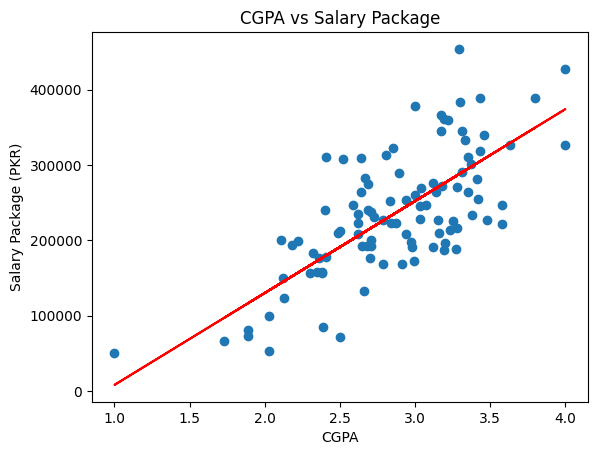

In [ ]:
plt.scatter(df['cgpa'],df['salary'])
plt.plot(x_train,lr.predict(x_train),color='red')
plt.xlabel("CGPA")
plt.ylabel("Salary Package (PKR)")
plt.title("CGPA vs Salary Package")

In [ ]:
m = lr.coef_
print(m)

[121990.17585119]


In [ ]:
c = lr.intercept_
print(c)

-113882.85801352107


In [ ]:
# y = mx+c
y = m * 2.62 + c

In [ ]:
print(y)

[205731.40271661]


In [ ]:
y = m * 5.00 + c

In [ ]:
y

array([496068.02124245])

In [ ]:
y_perdict = lr.predict(x_test)

In [ ]:
y_test

,salary
26,360000
86,223000
2,264000
55,308000
75,291000
93,323000
16,276000
73,196000
54,209000
95,99000


In [ ]:
print("MAE",mean_absolute_error(y_test,y_perdict))

MAE 39743.902428911155


In [ ]:
print("MSE",mean_squared_error(y_test,y_perdict))

MSE 2815392922.0335903


In [ ]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_perdict)))

RMSE 53060.27630943501
